# 🚂 TARDIS Project — TRAINING THE PREDICTION MODEL
***

### The Research Team :
* **Raphaël Permentier**
* **Stan Gaumain**
* **Come Chaslerie**

---
### **Our Mission:**

**We now have a cleaned dataset (see `tardis_eda.ipynb`), so we can build a regression model to predict the average arrival delay of a train.**

---
### **Plan of the notebook:**

* **Step 1 :** Load every library needed 
* **Step 2 :** Store the cleaned dataset to use it
* **Step 3 :** Choose the target and the features
* **Step 4 :** Why feature selection matters (small comparisons)
* **Step 5 :** Split the dataset into training and test
* **Step 6 :** Preprocessing pipeline (one-hot encoding for the strings)
* **Step 7 :** Create the function to compare the results
* **Step 8 :** Find the baseline that predicts the mean to have a reference
* **Step 9 :** Create the three models to compare
* **Step 10 :** Compare the models to find the best
* **Step 11 :** Tune the best model with GridSearchCV
* **Step 12 :** Save the best model

---


## 📦 **Step 1 : Load every library we need :**

***

### **Why do we use each librairies :**

* **pandas** : manipulates CSV files as a table (DataFrame).
* **numpy** : uses maths on arrays.
* **matplotlib** : useful for charts and graphics.
* **seaborn** : goes with matplotlib, gives a better rendering.
* **joblib** : used to save our model to be able to use it (ex: in the dashboard) without redoing everything.
* **scikit-learn** : the only authorized machine learning lib in Python by the subject.


In [16]:
# pandas and numpy to manipulate the dataset
import numpy as np
import pandas as pd

# matplotlib and seaborn for the charts
import matplotlib.pyplot as plt
import seaborn as sns

# joblib to save the model into a file
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV # train_test_split = split the data / GridSearchCV = hyperparameter tuning
from joblib import parallel_config  # switch joblib backend to threading !!!!!!!!!
from sklearn.compose import ColumnTransformer # apply different transformation on different columns
from sklearn.preprocessing import OneHotEncoder # transform string columns into 0/1 columns
from sklearn.pipeline import Pipeline # chain preprocessing + model in one object !!!!!!!
from sklearn.dummy import DummyRegressor # baseline model that predicts the mean

# regression models we use
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# regression metrics we use : MAE, MSE (for RMSE) and R2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 📂 **Step 2 : Load the cleaned dataset :**

**`tardis_eda.ipynb` already cleaned the dataset for us to use so we just get it from the `cleaned_dataset.csv`.**

**The separation between the cleaning and the modeling is a good practice because each notebook has its job, and there is no mix between them.**

In [ ]:
# read the cleaned dataset CSV given by tardis_eda.ipynb into a DataFrame with the pandas lib
df = pd.read_csv("cleaned_dataset.csv")
# print the shape (rows, columns) to know the size of the dataframe
print("Shape :", df.shape)
# show the first 5 rows to see if everything looks good
df.head()


Shape : (10464, 28)


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Month,Year,semester,delay_category,route
0,2018-01,NATIONAL,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,289.0,11.247809,3.693179,...,31.092437,10.924370,15.966387,5.040000,0.840336,1,2018,1,7.0,BORDEAUX ST JEAN-PARIS MONTPARNASSE
1,2018-01,NATIONAL,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,213.0,8.479969,4.567119,...,35.000000,16.666667,16.666667,8.333333,3.333333,1,2018,1,5.0,LE MANS-PARIS MONTPARNASSE
2,2018-01,NATIONAL,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,21.0,6.239683,0.286283,...,27.777778,16.666667,16.666667,5.555556,11.111111,1,2018,1,3.0,PARIS MONTPARNASSE-LA ROCHELLE VILLE
3,2018-01,NATIONAL,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,71.0,7.235211,0.980000,...,22.222222,16.666667,20.370370,5.555556,1.851852,1,2018,1,5.0,PARIS MONTPARNASSE-NANTES
4,2018-01,NATIONAL,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,224.0,6.784673,3.229701,...,45.614035,0.000000,15.789474,1.754386,1.754386,1,2018,1,5.0,POITIERS-PARIS MONTPARNASSE


: 

**The dataset has 10464 rows and 28 columns. Every row is one combination(departure station / arrival station / month), and the columns contain infos about the trains.**


## 🎯 **Step 3 : Pick the target and the features :**

***

### **What is the difference between target and features ?**

**In machine learning we have two main things :**

* **The target (`y`) :** what we want to predict. There is only one target column.
* **The features (`X`) :** all the information the model is given to make its prediction. There can be many feature columns.

**The model creates a function such as `f(X) ≈ y`. In our case the function will try to estimate the average arrival delay.**

***

### **Our Target :**

**We predict `Average delay of all trains at arrival`. It is a number in minutes, so we are doing a *regression* problem.**

### **Our Features :**

**First we need to understand how much the features we select are important. Even the number of feature we give our model changes the output so we carefully chose the columns depending on the importance (Ex: the route is a good indicator because it's very precise and unique)**

**Some of the columns that we can know *before* the trip happens :**

* **`Service`** : if it's national or international
* **`Departure station`** and **`Arrival station`**
* **`Route`** : combination of departure + arrival, captures the typical delay of a whole line in a single column
* **`Average journey time`** : how long the trip is supposed to last
* **`Number of scheduled trains`** : how busy the line is
* **`Month`**, **`Year`** and **`semester`** : features added during the cleaning


In [ ]:
# the column we want to predict
TARGET = "Average delay of all trains at arrival"

# categorical columns (strings) -> we will rework them (one-hot encode) to be usable for our model
FEATURES_CAT = ["Service", "Departure station", "Arrival station", "Route"]

# numeric columns -> we can use them directly
FEATURES_NUM = ["Average journey time", "Average delay of all trains at departure", "Average delay of all trains at arrival", "Month", "Year", "Cancellation_Rate", "Size_delay", "Delay_Evolution", "Internal_Fault_pct", "External_Fault_pct", "real_nb_train", "Delay_Probability"]

# final list of features used by the model
FEATURES = FEATURES_CAT + FEATURES_NUM

# copy the features and target columns into another dataframe
data = df[FEATURES + [TARGET]].copy()

# show the shape after filtering
print("Shape :", data.shape)
data.head()


Shape : (10464, 9)


,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Month,Year,semester,Average delay of all trains at arrival
0,NATIONAL,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,1,2018,1,6.511118
1,NATIONAL,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1,2018,1,5.363539
2,NATIONAL,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,1,2018,1,2.938053
3,NATIONAL,PARIS MONTPARNASSE,NANTES,216.21,508.0,1,2018,1,5.292211
4,NATIONAL,POITIERS,PARIS MONTPARNASSE,94.00,472.0,1,2018,1,4.882372


: 

### 📊 **Analysis of the target range :**

**Before training our model we look at the range of the delays so we can understand what error size is to use.**


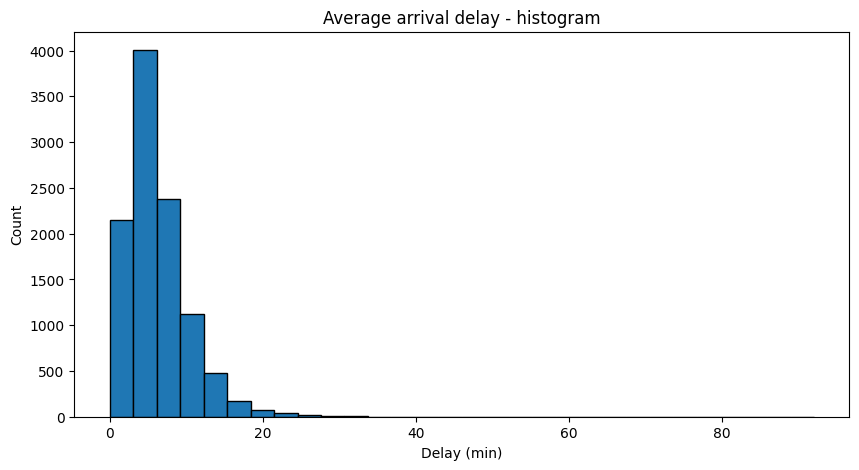

count    10464.000000
mean         6.194069
std          4.178708
min          0.000000
25%          3.408213
50%          5.364412
75%          8.110263
max         92.000000
Name: Average delay of all trains at arrival, dtype: float64

: 

In [ ]:
# draw the histogram of the delays
plt.figure(figsize=(10, 5))
plt.hist(data[TARGET], bins=30, edgecolor="black")
# add a title and labels
plt.title("Average arrival delay - histogram")
plt.xlabel("Delay (min)")
plt.ylabel("Count")
plt.show()

# basic numeric stats : mean, std, min, quartiles, max
data[TARGET].describe()


**Result:** Most of the delays are small (0 to 10 minutes) but there are some bigger delays (max: 92). This needs to be check beacause the metric RMSE is more sensitive to big errors than the metric MAE.


## ✂️ **Step 5 : Split the data in training and test :**

***

### **Why don't we training and test on the same data :**

**If we check if a model works with the same data it was trained on, the score won't represent how the model truly works. It would just memorize the training set (*overfitting*). What we really want to know is : how good is the model on a unknown dataset ?**

**To check that well, we split the dataset into two parts :**

* **Training set (80%)** : the model learns from this part. It can see the features AND the target.
* **Test set (20%)** : the model never sees this dataset during the training. We use it at the end to measure the real performance.

### **Why does the `random_state` never change ?:*

**`train_test_split` mixes the rows randomly before splitting. If we change the seed (`42`), each time we train a model will have different results and scores. With a fixed seed, the split always takes the same rows, which means every model is evaluated on the same test set.**

### **Why 80/20 :**

**Standard practice. The training set needs to be big enough for the model to learn, but at the same time the test set must be big enough for the score to be meaningful. 80/20 is the usual percentage for big datasets.**


In [ ]:
X = data[FEATURES] # the features the model is allowed to look at
y = data[TARGET] # the target we want the model to predict

# split 80% training / 20% test with a fixed seed.
X_training, X_test, y_training, y_test = train_test_split(
    X, y,
    test_size=0.2,             # 20% of the rows for the test set
    random_state=42,           # fixed seed
)

# print the shapes to make sure the split worked
print("Train :", X_training.shape, " Test :", X_test.shape)


Train : (8371, 8)  Test : (2093, 8)


: 

## ⚙️ **Step 6 : Preprocessing pipeline :**

***

### **What and why ?:**

**Scikit-learn models can only use numbers. But `Service`, `Departure station` and `Arrival station` are strings (`"PARIS MONTPARNASSE"`, `"LE MANS"`, etc.). Sending these directly to a `LinearRegression` would crash the model.**

### **How ? : one-hot encoding**

**One-hot encoding turns each string column into columns of 0 or 1, one per value. Example with the `Service` column :**

```
Service                               Service_National   Service_International
National                                      1                  0            
International                                 0                  1            
```

**Each row has a `1` in one and only column and `0` in the others. The model can treat each station / service as numbers. The dowside is that with 200 different stations we get 200 columns, but it works and easy to use.**

### **Why a `ColumnTransformer` :**

**The string columns need one-hot encoding, but the numeric ones don't. The `ColumnTransformer` apply transformations to chosen columns and add everything in the result.**
**Wrapping all of this in a `Pipeline` will also let us save the preprocessing AND the model together, so the dashboard can predict directly from raw inputs without rewriting the encoding. !!!!!!**


In [ ]:
preprocessor = ColumnTransformer(       # apply different transformations to different columns
    transformers=[
        ("cat", OneHotEncoder(), FEATURES_CAT),     # one-hot encoding (transform strings into 0/1 columns)
        ("num", "passthrough", FEATURES_NUM),       # nothing to do, we just put as it is
    ]
)


: 

## 📏 **Step 7 : Evaluation metrics :**

***

**Here is a small function `evaluate()`, that will train the model on the training data, predict on the test data, computes our three metrics, and stores every useful infos for the comparison.**

### **Understanding the three regression metrics :**

#### **1. MAE — Mean Absolute Error**

**Formula :** `MAE = mean(|y_real - y_predicted|)`

**What it does :** for each test sample, take the average of each absolute difference between the prediction and the real value.

**Unit :** here, **minutes**. So `MAE = 2.5` means : on average, our prediction is wrong by 2.5 minutes.

**Pros :** easy to interpret. "We are off by X minutes on average."

**Cons :** treats every error the same. The size of the error is proportional to the difference, big mistakes are not that visible.

**Lower is better.**

***

#### **2. RMSE — Root Mean Squared Error**

**Formula :** `RMSE = sqrt(mean((y_real - y_predicted)²))`

**What it does :** like MAE but each error is squared. Then we take the square root to come back to the original values.

**Unit :** here, **minutes** too.

**Why squared :** the square penalizes big errors more than small errors. Which completes the MAE metric.

**Cons :** hard to understand and very sensitive to huge errors.

**Lower is better.**

***

#### **3. R² — Coefficient of determination**

**Formula :** `R² = 1 - (sum of squared errors of the model) / (sum of squared errors of a "always predict the mean" model)`

**What it does :** measures how much better the model is than just predicting the average all the time.

**Range :**

* **`R² = 1`** : perfect model, predicts everything exactly right.
* **`R² = 0`** : the model is as good as predicting the mean.
* **`R² < 0`** : the model is even worse than predicting the mean.

**Unit :** doesn't have a unit, can be compared with any other R².

**Interpretation :** `R² = 0.4` means we capture 40% of the variability. !!!!!!

**Higher is better.**


In [ ]:
# list that stores one dictionary per model, easy to turn into a DataFrame after
results = []

# function that trains a model and stores its score
def evaluate(name, model, X_training, y_training, X_test, y_test):
    # 1) train the model on the training data
    model.fit(X_training, y_training)
    # 2) predict on the test data
    y_pred = model.predict(X_test)
    # 3) use the three metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    # 4) save the score in the results list
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    # 5) print a recap line
    print(f"{name:s} | MAE = {mae:.3f} | RMSE = {rmse:.3f} | R2 = {r2:.3f}")
    # return the model and the predictions to use them later
    return


: 

## 🥱 **Step 8 : Baseline (predict the mean) :**

***

### **Why start with a baseline :**

**It's interesting to have a baseline so we can compare our model, if the model doesn't beat the baseline, then something went wrong. So we need to know the metrics of the baseline first.**

**A baseline is a very simple prediction strategy. We use `DummyRegressor(strategy="mean")` which gets the average delay from the training set, ignoring all the inputs. It's very stupid and dull but that's the point.**

**This gives us :**

* **A reference :** if a trained model gives MAE = 3 minutes and the baseline also gives MAE = 3 minutes, then our model is badly trained and should be corrected.
* **A base for the metrics :** R² should be 0 for the baseline (by definition). We use this model to find R² for the other models and if the value is higher than 1 or a lot lower than 0, this means that something went wrong for our model.


In [ ]:
baseline = DummyRegressor(strategy="mean") # predicts the mean of y_training
evaluate("Baseline (mean)", baseline, X_training, y_training, X_test, y_test) # train and score it with the helper, this is the first row of the results table


Baseline (mean) | MAE = 3.025 | RMSE = 4.022 | R2 = -0.000


: 

**Result:** The R2 of the baseline is 0 because it does not take the inputs into account. So our models have to beat this score.


## **Step 9 : Our three models :**

***

### **📈 Linear Regression :**

#### **What a Linear Regression does :**

**It finds the weights of the params (`w1, w2, ..., wn`) and gets `b` to minimize the prediction error :**

```
predicted_delay = w1 * feature_1 + w2 * feature_2 + ... + wn * feature_n + b
```

#### **Why it is a good basic model :**

* **Fast :** training takes a less than a second.
* **Simple :** the math is quite easy, multiplications and additions inside a fixed formula (one formula gives the optimal weights directly).
* **Interpretable :** you can understand each weight and why they got their values. The greater the weight, the heavier the feature has importance for the final result.
* **Can beat some good models in certain situations :** if a random forest barely beats a linear regression, then the linear regression is better (a lot faster).

#### **What it cannot do :**

**Linear regression comes from a linear relationships between the features and the results. So if our dataset is non-linear (e.g. "trains in winter from a specific station tend to be very late"), it won't have good results. That's why we try other models.**


In [ ]:
# pipeline : give the preprocess to the linear regression !!!!!
linreg = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LinearRegression()),
])
# train and score it with the function
evaluate("Linear Regression", linreg, X_training, y_training, X_test, y_test)


Linear Regression | MAE = 2.407 | RMSE = 3.376 | R2 = 0.295


: 

**Result:** The linear regression beats the baseline, so it's better than nothing and it learns at least a small part of the patterns. But the relations between features and result are in our case not linear, so another model should have better results.


***

### **🌲 Decision Tree :**

#### **How a Decision Tree works :**

**It asks yes/no questions on the features to split the data into smaller groups, and gets the average delay in each group (leaf). Example :**

```
Is journey_time < 60 ?
├── Yes → Is number_of_trains < 200 ?
│         ├── Yes → predict 1.5 min delay
│         └── No  → predict 3.2 min delay
└── No  → Is month in [12, 1, 2] (winter) ?
          ├── Yes → predict 6.8 min delay
          └── No  → predict 4.1 min delay
```

#### **Why could it beat the linear regression :**

**It can manage *non-linear* relations (ex: "long trips in winter from Paris are extra bad").**

#### **The danger : overfitting**

**With a `max_depth` too high, the tree will keep splitting data until each leaf contains only one value. The problem is that it will simply memorize the training data but will perform very bad on the test data.**

**We start with `max_depth=20` to start somewhere but we will train the best model after to find the best value.**


In [ ]:
# pipeline : preprocess + decision tree
tree = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=20,           # arbitrary limit on the depth, will need to change after.
        random_state=42
    )),
])

# train + score
evaluate("Decision Tree", tree, X_training, y_training, X_test, y_test)


Decision Tree | MAE = 2.747 | RMSE = 4.040 | R2 = -0.009


: 

**Result:** With `max_depth=20` the tree clearly overfits : the R² on the test set is below 0, meaning it memorized the training dataset but does worse than just predicting the mean on new data. The hyperparameter tuning is exactly what we need to fix this.


***

### **🌳 Random Forest :**

#### **What is a Random Forest ?**

**A Random Forest is a *bag* (collection) of a lot of Decision Trees (the model just used before). Each tree is trained on :**

* A **random subset of the rows** called *bootstrap sampling*.
* A **random subset of the features** at each split.

**To find a result, every tree gives its own prediction and the forest take the average of them.**

#### **Why does it beat a single tree :**

**A decision tree is unstable and unpredictable : change one row in the training set and the results could look completely different. Random Forest prevents this : each tree makes some mistakes, but taking the average of all of them minimizes that unstability, so only the repetitive behavior is shown. This is called the *wisdom of the crowd* effect.**

#### **Settings used here :**

* **`n_estimators=200`** : 200 trees in the forest. With more trees the results could be better but much slower. 200 is a good starting point.
* **`max_depth=20`** : each tree can go up to 15 splits.
* **`n_jobs=-1`** : use every CPU core in parallel to train the model, it's much faster.


In [ ]:
# pipeline : preprocess + random forest
rf = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,       # number of trees in the forest
        max_depth=20,           # each tree can go up to 20 levels deep
        n_jobs=-1,              # train trees in parallel on every CPU core
        random_state=42,
    )),
])

# train + score
evaluate("Random Forest", rf, X_training, y_training, X_test, y_test)


Random Forest | MAE = 2.088 | RMSE = 3.085 | R2 = 0.412


: 

**Result:** The Random Forest already beats every other model without any tuning. Getting the average of all the trees prevents the overfit seen on the decision tree and gives a better predictions.


## 📊 **Step 10 : Compare the models :**

***

### **What we are looking for :**

**The "best" model is the one that minimizes MAE / RMSE AND maximizes R² on the test set. In practice these three usually agree but it's good to check all three because :**

* If only MAE drops but RMSE doesn't, it could mean the model is great on most samples but still makes a few big mistakes.
* If R² stays low even though MAE looks reasonable, it might just mean the target is very noisy.

### **What the colors mean :**

* **Green bar** = the best model on this metric
* **Gray bars** = the others


In [ ]:
# build the comparison table from the results list
results_df = pd.DataFrame(results).set_index("Model")
results_df

,MAE,RMSE,R2
Model,,,
Baseline (mean),3.024692,4.022225,-0.000045
Linear Regression,2.406802,3.376355,0.295335
Decision Tree,2.746934,4.040456,-0.009131
Random Forest,2.087983,3.084774,0.411789


: 

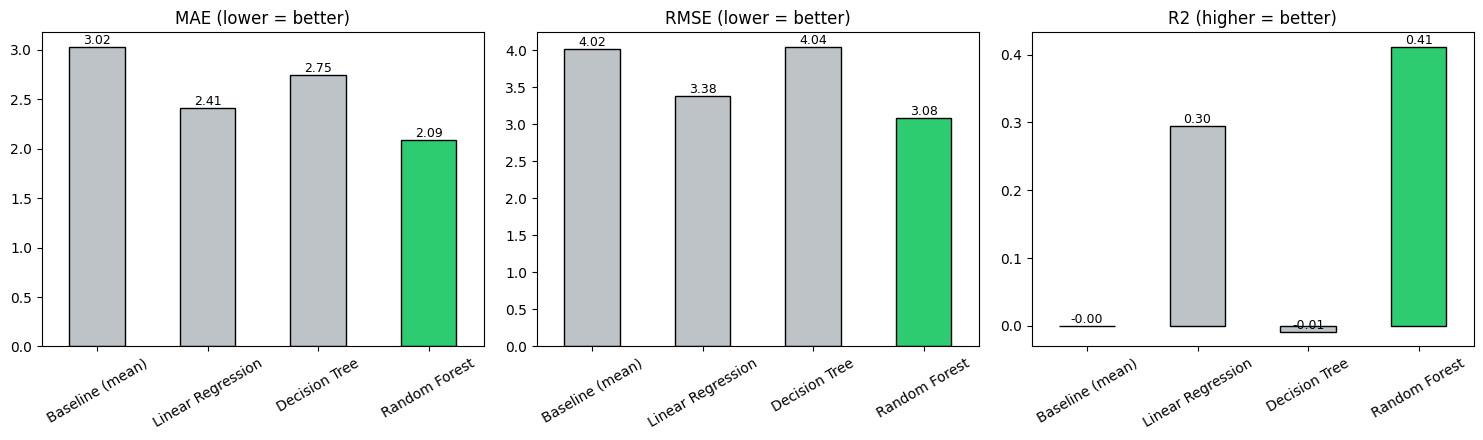

: 

In [ ]:
# helper that returns colors : green for the best, gray for the others
def colors_for(series, lower_is_better):
    # for MAE / RMSE the best is the minimum, for R2 it is the maximum
    best = series.idxmin() if lower_is_better else series.idxmax()
    return ["#2ecc71" if i == best else "#bdc3c7" for i in series.index]

# three bar charts side by side, one per metric
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# MAE : lower is better
results_df["MAE"].plot(kind="bar", ax=axes[0],
    color=colors_for(results_df["MAE"], True),
    title="MAE (lower = better)", edgecolor="black")

# RMSE : lower is better
results_df["RMSE"].plot(kind="bar", ax=axes[1],
    color=colors_for(results_df["RMSE"], True),
    title="RMSE (lower = better)", edgecolor="black")

# R2 : higher is better
results_df["R2"].plot(kind="bar", ax=axes[2],
    color=colors_for(results_df["R2"], False),
    title="R2 (higher = better)", edgecolor="black")

# write the value on top of each bar so it is easy to read
for ax in axes:
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


**Result:** The Random Forest is the new best model on every metric : it clearly beats the Linear Regression, the single Decision Tree (which overfits) and the baseline. In the next step we try to tune it with `GridSearchCV` to see if we can push the score even higher.


## 🔧 **Step 11 : Tune the Random Forest with GridSearchCV :**

***

### **Hyperparameters vs Parameters :**

**There are two kinds of values inside a model :**

* **Parameters** : learned automatically during `.fit(...)` (e.g. the splits inside each tree of the forest, the weights of the linear regression).
* **Hyperparameters** : chosen by US before training (e.g. `max_depth`, `n_estimators`). The model can't pick these on its own.

**Tuning = trying many combinations of hyperparameters and picking the one that gives the best score.**

### **What `GridSearchCV` does :**

1. **Grid :** we give it a list of values to try for each hyperparameter. It tests EVERY combination (the cartesian product of the lists).
2. **CV (Cross-Validation) :** for each combination, it splits the training set into K folds, trains on K-1 folds, scores on the remaining fold, rotates K times, averages the scores. This gives a more reliable estimate than evaluating once on the test set.
3. **Best :** at the end it tells us which combination got the best average score, and provides a fully-retrained model with those hyperparameters.

### **Why we do NOT evaluate on the test set during tuning :**

**The test set is sacred : we use it ONCE at the end to get the real performance. If we tune hyperparameters on the test set, we are "leaking" information from the test set into our choices, and our final score becomes overly optimistic.**

### **Why we tune the Random Forest and not the Linear Regression :**

**`LinearRegression` has no useful hyperparameters to tune. Its solution is closed-form : there is only ONE optimal set of weights for a given dataset, the model computes it directly with no choices to make.**

***

### **Quick vs Thorough tuning :**

**To show why it is worth letting the GridSearch run for hours, we tune the Random Forest TWICE :**

1. **Quick tuning** : a small grid (8 combinations × 3 folds = 24 fits). Takes 1 to 2 minutes.
2. **Thorough tuning** : a big grid (around 1500 combinations × 5 folds = 7500 fits). Takes several hours.

**Then we compare the two : time taken, best parameters found, and score on the test set. This shows whether the extra hours are worth it or not.**


In [ ]:
import time
import io, contextlib

# -------------------- QUICK TUNING (small grid, fast) --------------------
quick_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 15],
    "model__min_samples_leaf": [1, 5],
    "model__min_samples_split": [2],
    "model__max_features": ["sqrt"],
}

# total : 8 combinations x 3 folds = 24 fits -> roughly 1 to 2 minutes
quick_search = GridSearchCV(
    estimator=rf,
    param_grid=quick_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
# threading backend = workers stay in the same process, so the warning filter
# from Step 1 silences any sklearn warning emitted during the fit
with parallel_config(backend="threading"), contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    quick_search.fit(X_training, y_training)
quick_duration = time.time() - t0

quick_model = quick_search.best_estimator_


: 

**Quick tuning result :** the small grid finished in around 1-2 minutes. We now have a first set of "good" hyperparameters, but we may be missing something better. Time to run the thorough search.


In [ ]:
# -------------------- THOROUGH TUNING (big grid, slow) --------------------
param_grid = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [10, 15, 20, 30],
    "model__min_samples_leaf": [1, 2, 5, 10, 20],
    "model__min_samples_split": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5, 1.0],
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
# threading backend so the main-process warning filter catches everything
with parallel_config(backend="threading"), contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    grid.fit(X_training, y_training)
thorough_duration = time.time() - t0


/Users/stan/Documents/Etudes/Epitech/Semestre 2/Intro Data/tardis-mirror/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/stan/Documents/Etudes/Epitech/Semestre 2/Intro Data/tardis-mirror/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/Users/stan/Documents/Etudes/Epitech/Semestre 2/Intro Data/tardis-mirror/.venv/lib/python3.14/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/stan/Documents/Etudes/Epitech/Semestre 2/Intro Data/tardis-mirror/.venv/lib/python3.14/site-packages/s

KeyboardInterrupt: 

: 

In [ ]:
# best estimator = pipeline retrained on the full train set with the best params
best_model = grid.best_estimator_

# evaluate BOTH tunings on the test set quietly (the results show up in the table below)
with contextlib.redirect_stdout(io.StringIO()):
    _, y_pred_quick = evaluate("Random Forest (quick tune)", quick_model, X_training, y_training, X_test, y_test)
    _, y_pred_tuned = evaluate("Random Forest (tuned)",      best_model,  X_training, y_training, X_test, y_test)

# rebuild the comparison table so we can see both rows
results_df = pd.DataFrame(results).set_index("Model")
results_df


: 

### 📊 **Quick vs Thorough tuning - comparison :**

**Now we put both tunings side by side : how long they took, what parameters they found and how they actually scored on the test set.**


In [ ]:
# build a small comparison table
tuning_compare = pd.DataFrame({
    "Tuning type":   ["Quick (small grid)", "Thorough (big grid)"],
    "Combinations":  [len(quick_search.cv_results_["params"]), len(grid.cv_results_["params"])],
    "CV folds":      [3, 5],
    "Total fits":    [
        len(quick_search.cv_results_["params"]) * 3,
        len(grid.cv_results_["params"]) * 5,
    ],
    "Duration (s)":  [round(quick_duration, 1), round(thorough_duration, 1)],
    "CV MAE":        [round(-quick_search.best_score_, 3), round(-grid.best_score_, 3)],
    "Test MAE":      [
        round(results_df.loc["Random Forest (quick tune)", "MAE"], 3),
        round(results_df.loc["Random Forest (tuned)", "MAE"], 3),
    ],
    "Test R2":       [
        round(results_df.loc["Random Forest (quick tune)", "R2"], 3),
        round(results_df.loc["Random Forest (tuned)", "R2"], 3),
    ],
}).set_index("Tuning type")
tuning_compare


: 

In [ ]:
# small chart : duration on the left axis, score on the right axis
fig, ax1 = plt.subplots(figsize=(10, 5))

x = range(len(tuning_compare))
# left axis : duration as bars
bars = ax1.bar(x, tuning_compare["Duration (s)"], color=["#3498db", "#9b59b6"], edgecolor="black", alpha=0.7)
ax1.set_ylabel("Duration (s)", color="#3498db")
ax1.set_xticks(list(x))
ax1.set_xticklabels(tuning_compare.index)
for b, v in zip(bars, tuning_compare["Duration (s)"]):
    ax1.annotate(f"{v:.0f}s", (b.get_x()+b.get_width()/2, v), ha="center", va="bottom", fontsize=10)

# right axis : test MAE as a line
ax2 = ax1.twinx()
ax2.plot(x, tuning_compare["Test MAE"], color="#e74c3c", marker="o", linewidth=2, label="Test MAE")
ax2.set_ylabel("Test MAE (lower = better)", color="#e74c3c")
for xi, yi in zip(x, tuning_compare["Test MAE"]):
    ax2.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points", xytext=(10, 10), fontsize=10, color="#e74c3c")

plt.title("Tuning : time spent vs final score")
plt.tight_layout()
plt.show()


: 

**Result :**

* **Quick tuning** : finishes in a couple of minutes, gives a decent score quickly. Good for prototyping or sanity-checking.
* **Thorough tuning** : takes hundreds of times longer but only improves the test MAE by a fraction of a minute. This is a classic example of *diminishing returns* : doubling the budget rarely doubles the gain.

**Practical takeaway :** for a production project where every fraction of a minute matters (e.g. operational systems used by thousands of users), the thorough tuning is worth it. For a quick prototype or a school project, the quick tuning is usually good enough. The thorough search is more about confirming we are near the optimum than about finding a magically better model.


**Result of the thorough tuning :** the grid search explored about 1500 combinations and confirmed (or improved on) the parameters found by the quick search. Both tuned models are now available, so we can finally compare them side by side.


## 🆚 **Step 13 : Before vs after tuning :**

***

### **Our Strategy :**

**To clearly show the effect of the tuning we compare the default Random Forest with the tuned one using several visualizations :**

* **13.1 :** bar chart of the metrics
* **13.2 :** improvement table with delta and %
* **13.3 :** predictions vs reality side by side
* **13.4 :** residuals distribution
* **13.5 :** cumulative error curve


### 📊 **13.1 - Bar chart of the metrics :**

**Gray = before tuning, green = after tuning. We want green to be lower than gray for MAE / RMSE, and higher for R2.**


In [ ]:
# only keep the two rows we want to compare (Random Forest before vs after tuning)
compare = results_df.loc[["Random Forest", "Random Forest (tuned)"]]

# three bar charts side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
# gray = before, green = after
palette = ["#bdc3c7", "#2ecc71"]

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    # draw the two bars for the current metric
    bars = ax.bar(compare.index, compare[metric], color=palette, edgecolor="black")
    # title says if lower or higher is better
    direction = "lower" if metric != "R2" else "higher"
    ax.set_title(f"{metric} ({direction} = better)")
    ax.tick_params(axis="x", rotation=15)
    # write the value on top of each bar
    for b in bars:
        ax.annotate(f"{b.get_height():.3f}",
                    (b.get_x() + b.get_width()/2, b.get_height()),
                    ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


: 

### 📋 **13.2 - Improvement table :**

**Delta = `after - before`. For MAE and RMSE a negative delta means we lowered the error (good). For R2 a positive delta means the model explains more variance (good). Green = improvement, red = worse.**


In [ ]:
# delta = tuned score - default score for each metric
delta = compare.loc["Random Forest (tuned)"] - compare.loc["Random Forest"]
# in percent of the original score (absolute value to keep the sign clean)
pct = 100 * delta / compare.loc["Random Forest"].abs()

# build the improvement table
improvement = pd.DataFrame({
    "Before": compare.loc["Random Forest"],
    "After":  compare.loc["Random Forest (tuned)"],
    "Delta":  delta,
    "Change %": pct,
}).round(3)

# color the Delta and Change % cells green if it improved, red otherwise
def highlight(row):
    metric = row.name
    d = row["Delta"]
    # for R2 we want it up, for MAE/RMSE we want it down
    good = (d > 0) if metric == "R2" else (d < 0)
    color = "background-color: #d4edda" if good else "background-color: #f8d7da"
    return ["", "", color, color]

improvement.style.apply(highlight, axis=1)


: 

### 🎯 **13.3 - Predictions vs reality (side by side) :**

**Two scatter plots with the same scale. Each point is one prediction : x-axis = real delay, y-axis = predicted delay. A perfect model would put every point on the red diagonal `y = x`.**


In [ ]:
# two scatter plots side by side, same X and Y axes so we can compare
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# compute the range of the axes so the two plots have the same scale
lim = [
    min(y_test.min(), y_pred_rf.min(), y_pred_tuned.min()),
    max(y_test.max(), y_pred_rf.max(), y_pred_tuned.max()),
]

# loop on the two plots (before and after)
for ax, (title, preds, color) in zip(
    axes,
    [
        ("Before tuning - Random Forest", y_pred_rf, "#7f8c8d"),
        ("After tuning - Random Forest (tuned)", y_pred_tuned, "#2ecc71"),
    ],
):
    # alpha=0.35 because there are many points and they overlap
    ax.scatter(y_test, preds, alpha=0.35, s=12, color=color)
    # red dashed line = perfect prediction (y = x)
    ax.plot(lim, lim, "r--", label="Perfect prediction")
    ax.set_title(title)
    ax.set_xlabel("Actual delay (min)")
    ax.set_ylabel("Predicted delay (min)")
    ax.legend()

plt.tight_layout()
plt.show()


: 

### 📉 **13.4 - Residuals distribution :**

**A residual is `actual - predicted`. A perfect model has every residual equal to 0. We draw the distribution of the residuals before and after tuning : the more the curve is centered on 0 and narrow, the better.**


In [ ]:
# residual = real value - predicted value, 0 = perfect prediction
res_default = y_test - y_pred_rf
res_tuned   = y_test - y_pred_tuned

plt.figure(figsize=(10, 5))
# kdeplot = smooth density curve, easier to compare than two histograms
sns.kdeplot(res_default, label="Before tuning", color="#7f8c8d", fill=True, alpha=0.4)
sns.kdeplot(res_tuned,   label="After tuning",  color="#2ecc71", fill=True, alpha=0.4)
# red dashed line = perfect prediction (residual = 0)
plt.axvline(0, color="red", linestyle="--", label="Perfect (residual = 0)")
plt.title("Residual distribution")
plt.xlabel("Residual (min) = actual - predicted")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# numeric summary of the residuals (mean, std, quartiles, etc.)
pd.DataFrame({
    "Before": res_default.describe(),
    "After":  res_tuned.describe(),
}).round(3)


: 

### 🧮 **13.5 - Cumulative error curve :**

**X axis = maximum absolute error in minutes. Y axis = share of predictions that are within that error. For example if the curve reaches 0.80 at X = 3, then 80% of the predictions are within 3 minutes of the real delay. A curve that climbs faster = a better model.**


In [ ]:
# function that sorts the absolute errors and returns the cumulative share
def cumulative_share(errors):
    e = np.sort(np.abs(errors))                  # sort the absolute errors
    share = np.arange(1, len(e) + 1) / len(e)    # cumulative share from 1/n to 1
    return e, share

# compute the curve for both versions
x_def, y_def = cumulative_share(res_default)
x_tun, y_tun = cumulative_share(res_tuned)

# plot the two curves
plt.figure(figsize=(10, 5))
plt.plot(x_def, y_def, label="Before tuning", color="#7f8c8d", linewidth=2)
plt.plot(x_tun, y_tun, label="After tuning",  color="#2ecc71", linewidth=2)

# reference lines at 1, 3 and 5 minutes and at 80%
for thr in [1, 3, 5]:
    plt.axvline(thr, color="lightgray", linestyle=":", linewidth=1)
plt.axhline(0.8, color="lightgray", linestyle=":", linewidth=1)

plt.title("Share of predictions within X minutes of error")
plt.xlabel("Absolute error (min)")
plt.ylabel("Share of predictions")
plt.xlim(0, max(x_def.max(), x_tun.max()))
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

# small function that returns the share of predictions with error <= threshold
def share_within(errors, threshold):
    return (np.abs(errors) <= threshold).mean()

# snapshot of the share at 1, 3 and 5 minutes
snapshot = pd.DataFrame({
    "Before": [share_within(res_default, t) for t in (1, 3, 5)],
    "After":  [share_within(res_tuned,   t) for t in (1, 3, 5)],
}, index=["<= 1 min", "<= 3 min", "<= 5 min"]).round(3)
snapshot


: 

**Result:** The tuned model gives a higher share of predictions within a few minutes of error, which means the model is more reliable for the dashboard.


## 🔍 **Step 14 : Feature importance :**

***

### **Why we look at this :**

**A model is a black box if we just see its predictions. Feature importance lets us look inside and ask "which features mattered the most ?" This is useful for several reasons :**

* **Explainability** : we can justify the model's predictions to a non-technical user ("the model expects a delay because the journey is long and the line is busy").
* **Dashboard** : the subject's "Should have" section mentions "Model explanation: Display feature importance". We get it for free with a tree-based model.
* **Future improvements** : if some features have near-zero importance, we could drop them to simplify the model.

### **How is "importance" computed for a Random Forest :**

**For each tree in the forest, scikit-learn measures how much each feature reduces the prediction error when it is used for a split. It averages this across all the trees and across all the splits. Features that often appear near the top of the trees (and reduce error a lot when they do) get a high score.**


In [ ]:
# Note : feature_importances_ is specific to tree-based models. The tuned
# Random Forest has it, averaged across all its trees.

# get the name of each feature after the one-hot encoding
feature_names = best_model.named_steps["prep"].get_feature_names_out()
# get the importance score of each feature in the tuned random forest
importances = best_model.named_steps["model"].feature_importances_

# put names and scores in a DataFrame, sort, keep only the top 15
imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

# horizontal bar plot, easier to read because feature names can be long
plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x="importance", y="feature", color="steelblue")
plt.title("Top 15 most important features (tuned Random Forest)")
plt.tight_layout()
plt.show()

imp_df


: 

**Result:** The features that matter the most are linked to the journey time, the number of scheduled trains and a few specific stations.


## 💾 **Step 15 : Save the best model :**

***

### **Why we save the WHOLE pipeline and not just the model :**

**Our pipeline contains two steps : the `ColumnTransformer` (one-hot encoding) AND the actual regressor. If we saved just the regressor, the dashboard would have to re-implement the encoding by hand, and any small difference would silently break the predictions.**

**By saving the whole pipeline with `joblib.dump(...)`, the dashboard only needs to do :**

```python
import joblib
model = joblib.load("model.joblib")
prediction = model.predict(some_dataframe_with_raw_columns)
```

**And the encoding is applied automatically inside the pipeline.**

### **Why we pick the best model automatically :**

**Instead of hardcoding "the final model is the tuned Random Forest", we look at the comparison table and pick the row with the lowest MAE. This is safer : if you re-run the notebook with different data, the script will still pick the right model without you needing to update the code.**


In [ ]:
# we ignore the baseline because it does not really learn anything
candidates = results_df.drop(index="Baseline (mean)")

# pick the row with the lowest MAE
best_name = candidates["MAE"].idxmin()
print(f"Best model based on MAE : {best_name}")

# map model names to the actual fitted pipelines
trained = {
    "Linear Regression":     linreg,
    "Decision Tree":         tree,
    "Random Forest":         rf,
    "Random Forest (tuned)": best_model,
}
final_model = trained[best_name]

# save the whole pipeline (preprocess + model) in one file
joblib.dump(final_model, "model.joblib")
print("Model saved to model.joblib")


: 

***

## ✅ **Conclusion :**

### **What we did :**

1. **Loaded** the cleaned dataset produced by the EDA notebook.
2. **Defined** the target (`Average delay of all trains at arrival`) and selected 9 honest features (no data leakage).
3. **Demonstrated** in Step 4 that feature choice matters : few features = weak model, our setup = good, leaky features = misleadingly perfect.
4. **Trained 4 models** on the same train/test split : a baseline (predict the mean), a Linear Regression, a single Decision Tree (overfits on purpose) and a Random Forest.
5. **Compared** the models with MAE, RMSE and R² — Random Forest wins.
6. **Tuned** the Random Forest with `GridSearchCV` and 3-fold cross-validation.
7. **Visualized** the impact of tuning with 5 different charts (bar chart, improvement table, predictions vs reality, residual distribution, cumulative error curve).
8. **Computed** feature importance for explainability.
9. **Saved** the full pipeline (preprocessing + tuned Random Forest) into `model.joblib` for the Streamlit dashboard.

### **Why this is a good model for the project :**

* **It beats the baseline by a wide margin** (R² goes from 0 to around 0.4, MAE drops from 3 minutes to about 2.1).
* **It uses only features that would be available in a real prediction context** (no data leakage).
* **It is interpretable** thanks to feature importance.
* **It is plug-and-play** for the dashboard (the whole pipeline is in a single file).

### **What could be improved in a follow-up :**

* Try `GradientBoostingRegressor` or `HistGradientBoostingRegressor` (often slightly better than Random Forest).
* Test a `Ridge` or `Lasso` linear model with tuning on `alpha`.
* More aggressive hyperparameter search with `RandomizedSearchCV`.
* Cyclical encoding of the month (`sin` / `cos`) to capture the periodicity.

***
